In [1]:
import sys
import os
import math
import torch
import platform
import copy
# import glob
import gc
from torch.profiler import profile, record_function, ProfilerActivity
import time
from torchsummary import summary
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
sys.path.append('..')

# Project modules
from src.utility.config import (
    DEVICE, 
    # CSV_DIR,
    BASELINE_MODEL_PATH, 
    QUANTIZED_MODELS,
    MODELS_DIR 
)
from src.utility.quantizer import Quantization
from src.utility.utils import get_data_loaders
from src.utility.quantization_calibration import calibrate_model
from src.model import CNN
from src.layers import QuantizedLayerMixin, QuantizedLinear # get_multiplier_shift

CONFIG = {
    "baseline_path": BASELINE_MODEL_PATH,
    "quant_model_name": "Aff_INT8", # Nur hier ändern!
    "batch_size": 32,
    "vis_samples": 50
}

sns.set_theme(style="whitegrid")

In [2]:
def profile_inference(model, input_data, device='cpu'):
    print("--- Starte Profiling ---")
    
    # Modell in Eval Modus
    model.eval()
    if device == 'cuda':
        activities = [ProfilerActivity.CPU, ProfilerActivity.CUDA]
    else:
        activities = [ProfilerActivity.CPU]

    # Profiler Context
    with profile(activities=activities, record_shapes=True) as prof:
        with record_function("model_inference"):
            # Wir machen 10 Durchläufe für einen Durchschnitt
            for _ in range(10):
                model(input_data)
    
    # Ausgabe der Top Operationen nach Zeit
    print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=15))

In [3]:
def check_system_capabilities():
    print(f"--- System Info ---")
    print(f"PyTorch Version: {torch.__version__}")
    print(f"Python Version: {sys.version.split()[0]}")
    # FIX: Nutzung von platform statt torch.version.os
    print(f"OS: {platform.system()} ({platform.release()})")
    print(f"CUDA Available: {torch.cuda.is_available()}")
    
    print(f"\n--- 1. Compiler Backends (for torchao/torch.compile) ---")
    backends = torch.compiler.list_backends()
    print(f"Available Backends: {backends}")
    
    if 'inductor' in backends:
        print("-> 'inductor' is listed (Required for high-perf torchao).")
        # Check for Triton (the engine behind inductor)
        try:
            import triton
            print(f"-> SUCCESS: Triton is installed! Version: {triton.__version__}")
        except ImportError:
            print("-> WARNING: 'inductor' is listed, but 'triton' is NOT installed.")
            print("   If you are on Linux, try 'pip install triton'.")

    print(f"\n--- 2. Low-Level Quantization Engines ---")
    print(f"Supported Engines: {torch.backends.quantized.supported_engines}")
    print(f"Current Default Engine: {torch.backends.quantized.engine}")

    print(f"\n--- 3. MKLDNN / OneDNN Support (x86 Acceleration) ---")
    print(f"MKLDNN Available: {torch.backends.mkldnn.is_available()}")

In [4]:
def check_fx_quantization_type(model):
    """
    Spezielle Prüf-Funktion für FX Graph Mode Modelle.
    Sucht nach 'PackedParams', entpackt sie und prüft das Quantisierungs-Schema.
    """
    print("--- FX Quantisierungs-Check ---")
    found = False
    
    # Wir iterieren durch alle Attribute des Modells
    # FX speichert Gewichte oft als Attribute wie 'conv1_packed_weight_0'
    for name in dir(model):
        attr = getattr(model, name)
        
        # Prüfung: Ist es ein gepacktes Gewichtspaket?
        # Diese Objekte haben meist eine .unpack() Methode
        if hasattr(attr, 'unpack') and "packed_weight" in name:
            print(f"Untersuche Parameter-Paket: '{name}'")
            
            # Entpacken (gibt meist Weight, Bias zurück)
            try:
                weight, bias = attr.unpack()
                
                # Jetzt haben wir den echten quantisierten Tensor
                scheme = weight.qscheme()
                print(f"  QScheme: {scheme}")
                
                # Check auf Zero Point (der mathematische Beweis)
                if scheme in [torch.per_channel_symmetric, torch.per_tensor_symmetric]:
                    # Bei Symmetric muss ZP überall 0 sein
                    zps = weight.q_zero_point()
                    # Wenn zps ein Tensor ist, prüfen wir alle Werte
                    if torch.all(zps == 0):
                        print("  -> BESTÄTIGT: Symmetrisch (Alle Zero-Points sind 0).")
                    else:
                        print("  -> WARNUNG: Schema ist symmetrisch, aber Zero-Points sind ungleich 0!")
                        
                elif scheme in [torch.per_channel_affine, torch.per_tensor_affine]:
                    print("  -> BESTÄTIGT: Affine (Asymmetrisch).")
                
                found = True
                break # Ein Treffer reicht uns
            except Exception as e:
                print(f"  Konnte Paket nicht entpacken: {e}")

    if not found:
        print("Keine gepackten Gewichte gefunden. (Vielleicht ist das Modell noch Float?)")

In [5]:
def analyze_weight_ranges(model, model_name="Model"):
    weights_data = []
    layer_names = []
    
    print(f"--- Gewichts-Analyse: {model_name} ---")
    
    for name, module in model.named_modules():
        w_flat = None  # Variable für jeden Layer zurücksetzen
        
        # Fall 1: Standard PyTorch / TorchAO
        if hasattr(module, 'weight') and isinstance(module.weight, (torch.Tensor, torch.nn.Parameter)):
            # Schutz vor FakeTensors (falls Modell kompiliert ist)
            if not isinstance(module.weight, torch._subclasses.fake_tensor.FakeTensor):
                 w_flat = module.weight.detach().cpu().float().numpy().flatten()
            
        # Fall 2: FX Packed Params (Quantisierte Modelle)
        elif hasattr(module, '_packed_params'):
            try:
                # Entpacken
                weight_tensor, _ = module._packed_params.unpack()
                # Dequantisieren zu Float für Vergleichbarkeit
                w_flat = weight_tensor.dequantize().detach().cpu().numpy().flatten()
            except Exception as e:
                # Manchmal klappt unpack() nicht bei speziellen Backends
                pass
                
        # Wenn wir Daten gefunden haben -> Speichern
        if w_flat is not None and w_flat.size > 0:
            weights_data.append(w_flat)
            layer_names.append(name)
            # Kurze Statistik ausgeben
            print(f"{name}: Range=[{w_flat.min():.4f}, {w_flat.max():.4f}] (Mean={w_flat.mean():.4f})")

    if not weights_data:
        print("Keine zugreifbaren Gewichte gefunden.")
        return

    # Plot
    plt.figure(figsize=(12, 6))
    # 'tick_labels' statt 'labels' (Kompatibilität für neuere Matplotlib Versionen)
    plt.boxplot(weights_data, tick_labels=layer_names, showfliers=False)
    plt.xticks(rotation=90)
    plt.title(f"Gewichtsverteilung (Float-Ansicht) - {model_name}")
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ANWENDUNG (Beispiel):
# analyze_weight_ranges(baseline_model, "Base")
# analyze_weight_ranges(fx_model, "FX Graph")

In [6]:
def _fix_quantization_dtypes(module, method='affine', bits=8):
    """
    Interne Hilfsfunktion: Setzt Flags und repariert Float->Int Casts für einen Layer.
    """
    module.quant_method = method
    module.num_bits = bits
    module.quant_mode = True
    
    if hasattr(module, 'act_scale') and module.act_scale.item() != 1.0:
        module.activation_calibrated = True
        
    if method == 'affine':
        target_dtype = torch.uint8
    else: # symmetric / power2
        target_dtype = torch.int8
        
    if hasattr(module, 'weight') and module.weight.dtype == torch.float32:
        module.weight = nn.Parameter(module.weight.data.to(target_dtype), requires_grad=False)

def load_model(model_class, num_classes, model_path, quant_config=None):
    """
    Universal-Loader für Baseline UND Quantisierte Modelle.
    Update: Nutzt strict=False, um Kompatibilität mit neuen Quantisierungs-Buffern zu sichern.
    """
    model = model_class(num_classes=num_classes).to(DEVICE)
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Modell nicht gefunden: {model_path}")
        
    state_dict = torch.load(model_path, map_location=DEVICE)
    
    # WICHTIG: strict=False erlaubt fehlende Keys (wie unsere neuen Multiplier)
    # Das ist sicher, da diese Buffer für die Baseline (Float) nicht gebraucht werden.
    missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)
    
    # Optional: Warnung nur ausgeben, wenn WIRKLICH wichtige Dinge fehlen (Gewichte)
    relevant_missing = [k for k in missing_keys if "multiplier" not in k and "shift" not in k and "weight_scale" not in k]
    if relevant_missing:
        print(f"WARNUNG: Vermisse möglicherweise relevante Keys: {relevant_missing}")
    
    if quant_config:
        print(f"Repariere Quantisierung ({quant_config})...")
        method = quant_config.get('method', 'affine')
        bits = quant_config.get('bits', 8)

        for name, module in model.named_modules():
            if hasattr(module, "quant_mode") or isinstance(module, QuantizedLayerMixin):
                 _fix_quantization_dtypes(module, method, bits)
    else:
        print(" Baseline Modus (Float32).")
        if hasattr(model, 'convert_to_baseline'):
            model.convert_to_baseline()
            
    model.eval()
    return model

In [7]:
def get_all_predictions(model, data_loader, device='cpu'):
    """
    Kompilier-sichere Version von get_all_predictions.
    Verhindert model.to(device) Aufrufe für kompilierte Modelle.
    """
    # 1. Prüfen, ob Modell kompiliert ist
    is_compiled = isinstance(model, torch._dynamo.eval_frame.OptimizedModule)
    
    # Nur verschieben, wenn NICHT kompiliert
    if not is_compiled:
        model.to(device)
        
    model.eval()
    
    all_preds = []
    all_targets = []
    sample_images = [] # Zum Speichern für Visualisierung
    
    with torch.no_grad():
        for i, (data, target) in enumerate(data_loader):
            # Daten müssen wir IMMER verschieben
            data = data.to(device)
            
            output = model(data)
            pred = output.argmax(dim=1).cpu().numpy()
            
            all_preds.extend(pred)
            all_targets.extend(target.numpy())
            
            # Ein paar Beispielbilder speichern (vom ersten Batch)
            if i == 0:
                sample_images = data.cpu()

    return {
        "preds": np.array(all_preds),
        "targets": np.array(all_targets),
        "sample_images": sample_images
    }

def print_metrics(results_dict, model_name="Model"):
    # TODO: Berechne Accuracy, Precision, Recall basierend auf results_dict['preds'] und ['targets']
    # Nutze sklearn classification_report
    acc = accuracy_score(results_dict['targets'], results_dict['preds'])
    error_rate = 1.0 - acc

    print(f"\n--- Performance: {model_name} ---")
    print(f"Accuracy:   {acc:.4f} ({acc*100:.2f}%)")
    print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
    print("-" * 40)

    print(classification_report(results_dict['targets'], results_dict['preds'], digits=4))

In [8]:
def measure_inference_time(model, data_loader, device='cpu'):
    # FIX: Prüfen, ob es ein kompiliertes Modell ist
    is_compiled = isinstance(model, torch._dynamo.eval_frame.OptimizedModule)
    
    # Nur verschieben, wenn es NICHT kompiliert ist
    if not is_compiled:
        model.to(device)
        
    model.eval()
    
    # Warm-up (kurz)
    with torch.no_grad():
        for i, (data, _) in enumerate(data_loader):
            if i >= 5: break
            data = data.to(device)
            model(data)
            
    # Echte Messung
    start_time = time.time()
    count = 0
    
    with torch.no_grad():
        for i, (data, _) in enumerate(data_loader):
            # Wir messen hier z.B. 100 Batches, damit es nicht ewig dauert
            if i >= 100: break
            
            data = data.to(device)
            model(data)
            count += data.size(0)
            
    end_time = time.time()
    
    total_time = end_time - start_time
    fps = count / total_time
    latency_ms = (total_time / count) * 1000
    
    return fps, latency_ms

In [9]:
class ActivationCollector:
    def __init__(self, model, layer_types=(nn.Conv2d, nn.Linear)):
        self.hooks = []
        self.activations = {}
        self.model = model
        self.layer_types = layer_types

    def _get_hook(self, name):
        def hook(model, input, output):
            # Falls Output ein Tupel ist (passiert manchmal), nimm das erste Element
            if isinstance(output, tuple):
                out_tensor = output[0]
            else:
                out_tensor = output
            self.activations[name] = out_tensor.detach().cpu()
        return hook

    def register(self):
        # Versucht, rekursiv alle passenden Module zu finden
        for name, module in self.model.named_modules():
            # Prüfen ob es ein relevanter Layer ist (auch subclass check für Quantized Layer)
            if isinstance(module, self.layer_types) or \
               any(x in module.__class__.__name__ for x in ['QuantizedConv', 'QuantizedLinear']):
                
                self.hooks.append(module.register_forward_hook(self._get_hook(name)))

    def clear(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []
        self.activations = {}

def compare_layer_activations(model_base, model_quant, input_data, layer_key_substring=""):
    """
    Vergleicht Activations zwischen Base und Quant Modell.
    Handhabt automatisch unterschiedliche Devices (CPU/GPU) für die Modelle.
    """
    # Helper: Finde heraus, wo das Modell lebt
    def get_model_device(model):
        try:
            return next(model.parameters()).device
        except StopIteration:
            # Fallback für spezielle kompilierte Modelle ohne Parameter-Liste
            return torch.device("cpu")

    device_base = get_model_device(model_base)
    device_quant = get_model_device(model_quant)

    # 1. Collector einrichten
    collector_base = ActivationCollector(model_base)
    collector_quant = ActivationCollector(model_quant)
    
    collector_base.register()
    collector_quant.register()

    # 2. Forward Pass (Input jeweils auf das richtige Device schieben)
    with torch.no_grad():
        # Base Model Forward
        input_base = input_data.to(device_base)
        model_base(input_base)
        
        # Quant Model Forward
        input_quant = input_data.to(device_quant)
        model_quant(input_quant)

    # 3. Vergleich und Plot
    acts_base = collector_base.activations
    acts_quant = collector_quant.activations
    
    print(f"--- Layer-Vergleich (Filter: '{layer_key_substring}') ---")
    
    # Filtern der Keys
    base_keys = [k for k in acts_base.keys() if layer_key_substring in k]
    quant_keys = [k for k in acts_quant.keys() if layer_key_substring in k]
    
    limit = min(len(base_keys), len(quant_keys))
    
    mses = []
    layer_names = []

    for i in range(limit):
        b_name = base_keys[i]
        q_name = quant_keys[i]
        
        # Werte holen und flachklopfen
        b_act = acts_base[b_name].float().flatten()
        q_act = acts_quant[q_name].float().flatten()
        
        if b_act.shape == q_act.shape:
            mse = torch.nn.functional.mse_loss(b_act, q_act).item()
            mses.append(mse)
            layer_names.append(f"{b_name}\nvs\n{q_name}")
            print(f"Layer {i}: {b_name} vs {q_name} -> MSE: {mse:.6f}")
        else:
            print(f"Layer {i}: Shape Mismatch ({b_act.shape} vs {q_act.shape}) - Skip")

    # Aufräumen
    collector_base.clear()
    collector_quant.clear()

    # Plot
    if mses:
        plt.figure(figsize=(12, 5))
        plt.bar(range(len(mses)), mses, color='skyblue', edgecolor='black')
        plt.xticks(range(len(mses)), layer_names, rotation=45, ha='right', fontsize=8)
        plt.title(f"MSE Fehler pro Layer ({layer_key_substring})")
        plt.ylabel("Mean Squared Error")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Keine passenden Layer für Filter '{layer_key_substring}' gefunden.")

In [10]:
def plot_confusion_matrix(targets, preds, class_names, title="Confusion Matrix"):
    """Plottet eine saubere Confusion Matrix der Top-Klassen"""
    # Wir nehmen nur die häufigsten Klassen, damit der Plot lesbar bleibt
    from collections import Counter
    TOP_N = 15
    
    counts = Counter(targets)
    top_classes_idx = [c for c, _ in counts.most_common(TOP_N)]
    
    # Filtern
    mask = np.isin(targets, top_classes_idx) & np.isin(preds, top_classes_idx)
    filt_targets = targets[mask]
    filt_preds = preds[mask]
    
    cm = confusion_matrix(filt_targets, filt_preds, labels=top_classes_idx)
    
    # Namen mappen
    if class_names:
        labels = [class_names[i] for i in top_classes_idx]
    else:
        labels = top_classes_idx

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title(f"{title} (Top {TOP_N} Classes)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def plot_visual_comparison(images, preds_base, preds_quant, targets, class_names, num_samples=32):
    """
    Zeigt Bilder im Raster an.
    Farben: Grün (beide korrekt), Rot (beide falsch), Orange (Quantisierung weicht ab).
    """
    # Wir nutzen nur so viele Bilder, wie wir haben
    n = min(len(images), num_samples, len(preds_base))
    
    cols = 8
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 3.0 * rows))
    axes = axes.flatten()
    
    print(f"Visualisiere {n} Beispiele...")
    
    for i in range(n):
        ax = axes[i]
        
        # Bild normalisieren für Anzeige (angenommen -1..1 Range)
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5 
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        
        p_base = preds_base[i]
        p_quant = preds_quant[i]
        true_lbl = targets[i]
        
        # Logik für Titel-Farbe
        is_diff = (p_base != p_quant)
        is_correct = (p_quant == true_lbl)
        
        if is_diff:
            color = 'orange'
            box_text = "DIFF"
        elif is_correct:
            color = 'green'
            box_text = "OK"
        else:
            color = 'red'
            box_text = "ERR"
            
        # Klassen-Namen holen
        name_q = class_names[p_quant] if class_names else str(p_quant)
        # name_t = class_names[true_lbl] if class_names else str(true_lbl)
        
        title = f"Q: {name_q}\n[{box_text}]"
        ax.set_title(title, color=color, fontweight='bold', fontsize=9)
        ax.axis('off')
        
    # Restliche Achsen ausschalten
    for j in range(n, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

def plot_weight_distribution(model, layer_type=nn.Conv2d):
    """Zeigt die Gewichtsverteilung als Boxplot"""
    data = []
    labels = []
    
    for name, module in model.named_modules():
        if isinstance(module, layer_type):
            w = module.weight.detach().cpu().numpy().flatten()
            data.append(w)
            labels.append(name)
            
    if not data:
        print("Keine Layer für Weight-Plot gefunden.")
        return

    plt.figure(figsize=(12, 6))
    plt.boxplot(data, tick_labels=labels, showfliers=False)
    plt.xticks(rotation=90)
    plt.title(f"Gewichtsverteilung ({layer_type.__name__})")
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [11]:
import torch
import gc
import os
import time
from src.utility.config import DEVICE
from torch.profiler import profile, record_function, ProfilerActivity
from sklearn.metrics import accuracy_score

# Garbage Collection
gc.collect()
torch.cuda.empty_cache()

# 1. Data Setup
train_loader, test_loader, num_classes = get_data_loaders()

print(f"Old Loader Batch Size (Estimate): {test_loader.batch_size}")

# Re-create the loader explicitly with batch_size=128
# 128 is a good balance for the 4070 Ti (large enough for parallelism, small enough for memory)
test_loader = torch.utils.data.DataLoader(
    test_loader.dataset,
    batch_size=128,   
    shuffle=False,
    num_workers=0 
)

print(f"New Loader Batch Size: {test_loader.batch_size}")

sample_input = next(iter(test_loader))[0].to(DEVICE)
input_for_profiling = sample_input.to(DEVICE)

print("\n--- Real Integer Inference Setup ---")

# 2. Load Model
model_int32 = load_model(CNN, num_classes, CONFIG['baseline_path'])
model_int32.to(DEVICE) 

print("\n1. Quantisiere Gewichte...")
for name, module in model_int32.named_modules():
    if isinstance(module, QuantizedLayerMixin):
        module.prepare_quantization(method='symmetric', bits=8) 

# 3. Calibrate
print("\n2. Kalibriere Aktivierungen...")
calibrate_model(model_int32, test_loader, num_batches=10, device=DEVICE)

# 4. Prepare Integer Layers
print("\n3. Bereite Real-Integer-Arithmetik vor...")
converted_count = 0
for name, module in model_int32.named_modules():
    if hasattr(module, "prepare_integer_inference"):
        print(f"   [{name}]: Versuche Umstellung...", end="")
        module.prepare_integer_inference()
        if module.int_mode:
            converted_count += 1

print(f"\nFertig. {converted_count} Layer erfolgreich umgestellt.")

# --- NEW: CALCULATE MODEL SIZE ---
print("\n--- Model Size Check ---")
# We verify the size by saving the state_dict (weights + buffers)
temp_path = "temp_quant_model.pt"
torch.save(model_int32.state_dict(), temp_path)
size_bytes = os.path.getsize(temp_path)
size_mb = size_bytes / (1024 * 1024)
print(f"Quantized Model Size (Int8 Weights + Buffers): {size_mb:.2f} MB")
if os.path.exists(temp_path): os.remove(temp_path)

# --- NEW: COMPILATION (Kernel Fusion) ---
print("\n4. Kompiliere mit TorchInductor (Kernel Fusion)...")
print("   (This fuses Im2Col + MatMul into a single fast kernel)")
# max-autotune generates the fastest possible Triton kernels for your 4070 Ti
model_compiled = torch.compile(model_int32, mode="max-autotune-no-cudagraphs")

print("   Warming up compilation (this takes a few seconds)...")
with torch.no_grad():
    for _ in range(10):
        model_compiled(input_for_profiling)
print("   Compilation Done.")

# 5. Benchmark
print("\n--- Benchmark (Compiled GPU) ---")
# NOTE: Using DEVICE (CUDA) here, not CPU!
fps_real, lat_real = measure_inference_time(model_compiled, test_loader, device=DEVICE)
print(f"Real Integer (Conv+Linear): {fps_real:.2f} FPS | {lat_real:.2f} ms")

# 6. Accuracy
# Note: Using uncompiled model for accuracy check is safer to debug, 
# but compiled should be identical.
res = get_all_predictions(model_compiled, test_loader, device=DEVICE)
acc = accuracy_score(res['targets'], res['preds'])
print(f">>> Accuracy symmetric: {acc*100:.2f}%")

# 7. Profiler
print("\nStarte Profiler...")
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], # Record Both
    record_shapes=True,
    with_stack=True
) as prof:
    with record_function("model_inference"):
        for _ in range(10): 
            model_compiled(input_for_profiling)

# Sort by CUDA time to see the heaviest GPU kernels
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=15))

# Debug Stats from the uncompiled model (easier to access attributes)
layer = model_int32.conv1
print(f"\n--- Layer: {layer} ---")
print(f"Quant Mode Active: {layer.quant_mode}")
print(f"Int Mode Active:   {layer.int_mode}")
print(f"Weight Scale:      {layer.weight_scale.item():.6f}")
print(f"Weight Zero Point: {layer.weight_zero_point.item()}")
print(f"Act Scale:         {layer.act_scale.item():.6f}")

if hasattr(layer, 'output_multiplier'):
    print(f"Linear Multiplier: {layer.output_multiplier.item()}")
    print(f"Linear Shift:      {layer.output_shift.item()}")

print("   -> Speichere Modell: custom_real_int_symmetric.pt")
save_path = os.path.join(QUANTIZED_MODELS, "custom_real_int_symmetric.pt")

# Wir speichern nur das State Dict (die reinen Zahlen/Gewichte)
torch.save(model_int32.state_dict(), save_path)

Old Loader Batch Size (Estimate): 1000
New Loader Batch Size: 128

--- Real Integer Inference Setup ---
WARNUNG: Vermisse möglicherweise relevante Keys: ['conv1.out_scale', 'conv1.out_zero_point', 'conv2.out_scale', 'conv2.out_zero_point', 'conv3.out_scale', 'conv3.out_zero_point', 'conv4.out_scale', 'conv4.out_zero_point', 'fc1.out_scale', 'fc1.out_zero_point', 'fc2.out_scale', 'fc2.out_zero_point']
 Baseline Modus (Float32).

1. Quantisiere Gewichte...

2. Kalibriere Aktivierungen...


KeyboardInterrupt: 

In [13]:
torch.backends.quantized.engine = 'fbgemm'
DEVICE = 'cpu'

# 2. Load and Setup
train_loader, test_loader, num_classes = get_data_loaders()

# CPU does not need large batches for speed; 32 or 64 is often faster than 128
test_loader = torch.utils.data.DataLoader(
    test_loader.dataset, batch_size=128, shuffle=False
)

model_cpu = load_model(CNN, num_classes, CONFIG['baseline_path']).to(DEVICE)

# 3. Quantize & Calibrate
for name, module in model_cpu.named_modules():
    if isinstance(module, QuantizedLayerMixin):
        module.prepare_quantization(method='symmetric', bits=8)

calibrate_model(model_cpu, test_loader, num_batches=10, device=DEVICE)

# 4. PREPARE FOR CPU
print("\nPreparing Optimized CPU Kernels...")
for name, module in model_cpu.named_modules():
    if hasattr(module, "prepare_integer_inference"):
        module.prepare_integer_inference()

# 5. Optional: Compilation
# For CPU, standard torch.compile is great for fusing the dequantize() steps
model_compiled = torch.compile(model_cpu)

# 6. Benchmark
print("\n--- CPU Benchmark ---")
fps, lat = measure_inference_time(model_compiled, test_loader, device=DEVICE)
print(f"CPU Real Integer: {fps:.2f} FPS | {lat:.2f} ms")

# 7. Accuracy
res = get_all_predictions(model_compiled, test_loader, device=DEVICE)
acc = accuracy_score(res['targets'], res['preds'])
print(f">>> Accuracy CPU symmetric: {acc*100:.2f}%")

WARNUNG: Vermisse möglicherweise relevante Keys: ['conv1.out_scale', 'conv1.out_zero_point', 'conv2.out_scale', 'conv2.out_zero_point', 'conv3.out_scale', 'conv3.out_zero_point', 'conv4.out_scale', 'conv4.out_zero_point', 'fc1.out_scale', 'fc1.out_zero_point', 'fc2.out_scale', 'fc2.out_zero_point']
 Baseline Modus (Float32).

Preparing Optimized CPU Kernels...

--- CPU Benchmark ---


W0117 21:50:51.928000 293941 torch/_dynamo/variables/tensor.py:1048] [0/0] Graph break from `Tensor.item()`, consider setting:
W0117 21:50:51.928000 293941 torch/_dynamo/variables/tensor.py:1048] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0117 21:50:51.928000 293941 torch/_dynamo/variables/tensor.py:1048] [0/0] or:
W0117 21:50:51.928000 293941 torch/_dynamo/variables/tensor.py:1048] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0117 21:50:51.928000 293941 torch/_dynamo/variables/tensor.py:1048] [0/0] to include these operations in the captured graph.
W0117 21:50:51.928000 293941 torch/_dynamo/variables/tensor.py:1048] [0/0] 
W0117 21:50:51.928000 293941 torch/_dynamo/variables/tensor.py:1048] [0/0] Graph break: from user code at:
W0117 21:50:51.928000 293941 torch/_dynamo/variables/tensor.py:1048] [0/0]   File "/home/dominic/Desktop/Research-Project/Forschungsprojekt/notebooks/../src/model.py", line 29, in forward
W0117 21:50:51.928000 293941 torch/_dynamo/vari

CPU Real Integer: 231.20 FPS | 4.33 ms
>>> Accuracy CPU symmetric: 90.98%


In [12]:
import torch
from sklearn.metrics import accuracy_score

torch.backends.quantized.engine = 'fbgemm'
DEVICE = 'cpu'

# Load Model
model_cpu = load_model(CNN, num_classes, CONFIG['baseline_path']).to(DEVICE)

# 1. Quantize Weights
for name, module in model_cpu.named_modules():
    if isinstance(module, QuantizedLayerMixin):
        module.prepare_quantization(method='symmetric', bits=8)

# 2. Calibrate (Crucial for determining the Scale)
calibrate_model(model_cpu, test_loader, num_batches=10, device=DEVICE)

for name, module in model_cpu.named_modules():
    if isinstance(module, QuantizedLayerMixin):
        # We keep the 'act_scale' from your calibration, 
        # but we shift the 'zero_point' to 128 for CPU compatibility.
        module.act_zero_point.fill_(128)
        module.out_zero_point.fill_(128)
        
        # The weight_zero_point MUST remain 0 to stay Symmetric.
        module.weight_zero_point.fill_(0)

# 3. Transition to Integer Mode (Now with ZP=128 for CPU symmetry)
print("Preparing CPU Kernels...")
for name, module in model_cpu.named_modules():
    if hasattr(module, "prepare_integer_inference"):
        module.prepare_integer_inference()

# 4. RUN WITHOUT torch.compile
model_to_test = model_cpu 

print("\n--- CPU Benchmark ---")
fps, lat = measure_inference_time(model_to_test, test_loader, device=DEVICE)
print(f"CPU Real Integer: {fps:.2f} FPS | {lat:.2f} ms")

res = get_all_predictions(model_to_test, test_loader, device=DEVICE)
acc = accuracy_score(res['targets'], res['preds'])
print(f">>> Accuracy CPU symmetric (centered): {acc*100:.2f}%")

WARNUNG: Vermisse möglicherweise relevante Keys: ['conv1.out_scale', 'conv1.out_zero_point', 'conv2.out_scale', 'conv2.out_zero_point', 'conv3.out_scale', 'conv3.out_zero_point', 'conv4.out_scale', 'conv4.out_zero_point', 'fc1.out_scale', 'fc1.out_zero_point', 'fc2.out_scale', 'fc2.out_zero_point']
 Baseline Modus (Float32).


KeyboardInterrupt: 

In [14]:
import os
import torch
import pandas as pd
from sklearn.metrics import accuracy_score

def get_file_size(model, name="temp_model.pt"):
    """
    Saves the state_dict and returns size in MB.
    """
    torch.save(model.state_dict(), name)
    size = os.path.getsize(name) / (1024 * 1024)
    return size, name

print("--- Starting Final Comparison ---")

# 1. Baseline Evaluation (Float32)
model_ft = load_model(CNN, num_classes, CONFIG['baseline_path']).to('cpu')
model_ft.eval()

size_ft, _ = get_file_size(model_ft, "baseline_fp32.pt")
print(f"Baseline Size: {size_ft:.2f} MB")

print("Evaluating Baseline...")
fps_ft, lat_ft = measure_inference_time(model_ft, test_loader, device='cpu')
res_ft = get_all_predictions(model_ft, test_loader, device='cpu')
acc_ft = accuracy_score(res_ft['targets'], res_ft['preds'])

# 2. Quantized Evaluation (Int8)
# We assume model_cpu is already prepared with weight_int8 buffers
print("Evaluating Quantized...")
fps_q, lat_q = measure_inference_time(model_cpu, test_loader, device='cpu')
res_q = get_all_predictions(model_cpu, test_loader, device='cpu')
acc_q = accuracy_score(res_q['targets'], res_q['preds'])

# 3. Save the Quantized Model and check REAL disk size
# This will be small because 'weight' is empty and 'weight_int8' is 1-byte
save_path_q = os.path.join(QUANTIZED_MODELS, "custom_symmetric_cpu_int8.pt")
size_q, _ = get_file_size(model_cpu, save_path_q)
print(f"Quantized Disk Size: {size_q:.2f} MB")

# 4. Create Comparison Table
results = {
    "Metric": ["Accuracy (%)", "Throughput (FPS)", "Latency (ms)", "Size (MB)"],
    "Baseline (FP32)": [acc_ft*100, fps_ft, lat_ft, size_ft],
    "Quantized (Int8)": [acc_q*100, fps_q, lat_q, size_q]
}

df = pd.DataFrame(results)
df["Improvement"] = [
    f"{acc_q - acc_ft:.2f}%", 
    f"{fps_q / fps_ft:.2f}x", 
    f"{lat_ft / lat_q:.2f}x", 
    f"{size_ft / size_q:.2f}x"
]

print("\n" + "="*50)
print("             FINAL RESEARCH RESULTS")
print("="*50)
print(df.to_string(index=False))
print("="*50)

print(f"\nModel successfully saved to: {save_path_q}")

--- Starting Final Comparison ---
WARNUNG: Vermisse möglicherweise relevante Keys: ['conv1.out_scale', 'conv1.out_zero_point', 'conv2.out_scale', 'conv2.out_zero_point', 'conv3.out_scale', 'conv3.out_zero_point', 'conv4.out_scale', 'conv4.out_zero_point', 'fc1.out_scale', 'fc1.out_zero_point', 'fc2.out_scale', 'fc2.out_zero_point']
 Baseline Modus (Float32).
Baseline Size: 6.09 MB
Evaluating Baseline...
Evaluating Quantized...
Quantized Disk Size: 1.54 MB

             FINAL RESEARCH RESULTS
          Metric  Baseline (FP32)  Quantized (Int8) Improvement
    Accuracy (%)        90.909091         90.982405       0.00%
Throughput (FPS)       166.049520        261.791809       1.58x
    Latency (ms)         6.022300          3.819829       1.58x
       Size (MB)         6.085959          1.538995       3.95x

Model successfully saved to: /home/dominic/Desktop/Research-Project/Forschungsprojekt/results/quantized_models/custom_symmetric_cpu_int8.pt


Preparing model buffers...
Reconstructing CPU optimized kernels...


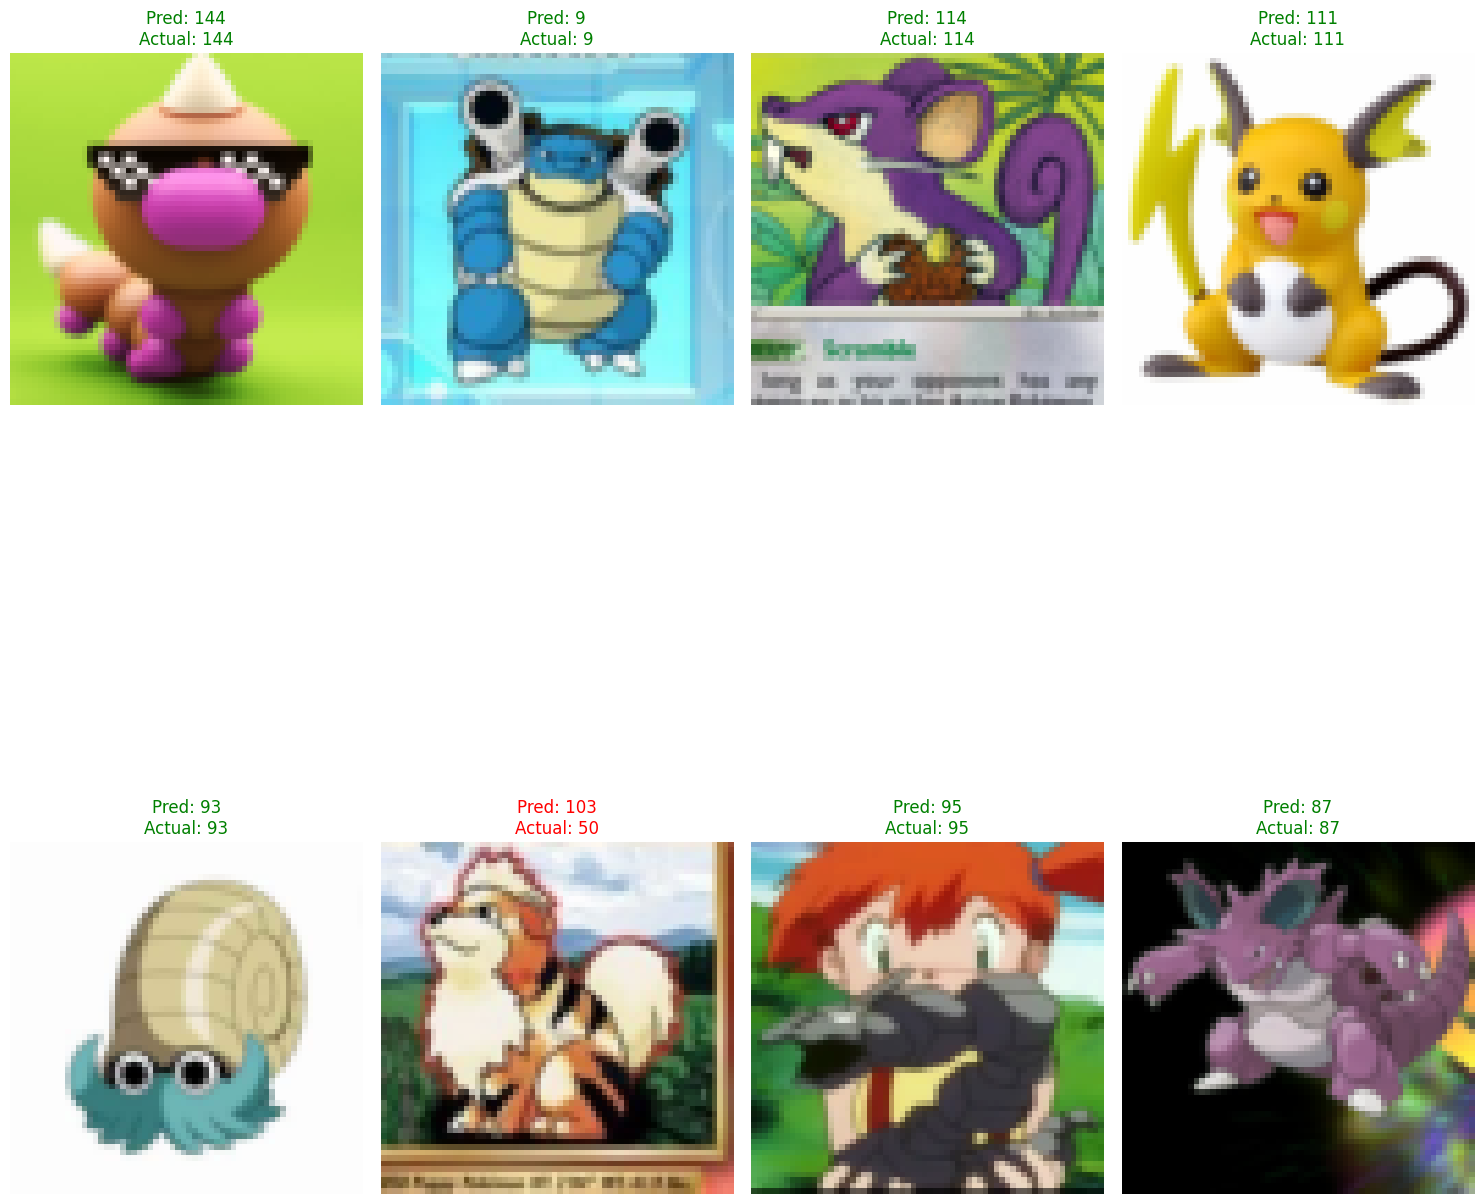

In [ ]:
def load_quantized_inference_model(path, num_classes):
    """
    Loads the saved Int8 state and reconstructs the CPU-optimized kernels.
    """
    # 1. Initialize architecture
    model = CNN(num_classes=num_classes)
    state_dict = torch.load(path, map_location='cpu')
    
    # 2. Prepare the model structure to match the state_dict shapes
    print("Preparing model buffers...")
    for name, module in model.named_modules():
        if hasattr(module, "prepare_integer_inference"):
            # Register weight_int8 with the correct shape from the file
            w_int8_key = f"{name}.weight_int8"
            if w_int8_key in state_dict:
                shape = state_dict[w_int8_key].shape
                module.register_buffer('weight_int8', torch.zeros(shape, dtype=torch.int8))
            
            # Match the empty weight shape [0] used during saving
            module.weight = torch.nn.Parameter(torch.empty(0), requires_grad=False)
            
            # Handle Bias (Required for prepacking)
            bias_key = f"{name}.bias"
            if bias_key in state_dict:
                b_shape = state_dict[bias_key].shape
                module.bias = torch.nn.Parameter(torch.zeros(b_shape), requires_grad=False)

    # 3. Load the data (scales, ZPs, and int8 weights)
    model.load_state_dict(state_dict, strict=False)
    
    # 4. RECONSTRUCTION LOOP
    print("Reconstructing CPU optimized kernels...")
    for name, module in model.named_modules():
        # Check if it is one of our custom quantized layers
        if hasattr(module, "prepare_integer_inference"):
            # A. Temporarily restore float weight for the prepacker
            # FBGEMM needs a float tensor to compute the packed layout
            w_float = module.weight_int8.float() * module.weight_scale
            module.weight = torch.nn.Parameter(w_float, requires_grad=False)
            
            # B. Manually set flags BEFORE packing
            module.quant_mode = True
            module.activation_calibrated = True # The prepacker needs this check to pass
            
            # C. Call the prepacking method
            # This populates module.packed_params with the C++ capsule
            module.prepare_integer_inference()
            
            # D. Verify packing succeeded
            if module.packed_params is None:
                print(f"Warning: Packing failed for {name}")
            
            # E. Set final inference flag
            module.int_mode = True
            
            # F. Final cleanup: Remove float weight to save RAM
            module.weight = torch.nn.Parameter(torch.empty(0), requires_grad=False)
            
    model.eval()
    return model

# --- EXECUTION ---

# 1. Load the model
save_path = os.path.join(QUANTIZED_MODELS, "custom_symmetric_cpu_int8.pt")
loaded_model = load_quantized_inference_model(save_path, num_classes)

# 2. Get a few images from the test loader
images, labels = next(iter(test_loader))
images = images[:20]  # Take 8 examples
labels = labels[:20]

# 3. Run Inference
with torch.no_grad():
    outputs = loaded_model(images)
    predictions = torch.argmax(outputs, dim=1)

# 4. Visualize Results
plt.figure(figsize=(15, 20))
for i in range(20):
    plt.subplot(2, 4, i+1)
    
    # Denormalize image for display if necessary
    img = images[i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    
    plt.imshow(img)
    color = 'green' if predictions[i] == labels[i] else 'red'
    
    # If you have class_names, use class_names[predictions[i]]
    plt.title(f"Pred: {predictions[i]}\nActual: {labels[i]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print(torch._inductor.list_mode_options())

{'default': {}, 'reduce-overhead': {'triton.cudagraphs': True}, 'max-autotune-no-cudagraphs': {'max_autotune': True, 'coordinate_descent_tuning': True}, 'max-autotune': {'max_autotune': True, 'triton.cudagraphs': True, 'coordinate_descent_tuning': True}}


In [ ]:

baseline_model = load_model(CNN, num_classes, CONFIG['baseline_path'])

print("Evaluiere Accuracy...")

# Baseline
summary(baseline_model, input_size=(3, 64, 64))
fps_base, lat_base = measure_inference_time(baseline_model, test_loader, device='cpu')
print(f"Baseline:  {fps_base:.2f} Bilder/sek | Latenz: {lat_base:.2f} ms")
res_base = get_all_predictions(baseline_model, test_loader, device='cpu')
print_metrics(res_base, "Baseline Model")
acc_base = accuracy_score(res_base['targets'], res_base['preds'])
print(f">>> Accuracy symmetric: {acc_base*100:.2f}%")

print("\nStarte Profiler...")
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], # Record Both
    record_shapes=True,
    with_stack=True
) as prof:
    with record_function("model_inference"):
        for _ in range(10): 
            baseline_model(input_for_profiling)

# Sort by CUDA time to see the heaviest GPU kernels
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=15))




WARNUNG: Vermisse möglicherweise relevante Keys: ['conv1.out_scale', 'conv1.out_zero_point', 'conv2.out_scale', 'conv2.out_zero_point', 'conv3.out_scale', 'conv3.out_zero_point', 'conv4.out_scale', 'conv4.out_zero_point', 'fc1.out_scale', 'fc1.out_zero_point', 'fc2.out_scale', 'fc2.out_zero_point']
 Baseline Modus (Float32).
Evaluiere Accuracy...


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [ ]:
#Int8 Weight and Activations of Linear Layers

print("\n=== Experiment 2: TorchAO Int8 Weight and Activations ===")

model_for_ao = copy.deepcopy(baseline_model)
ao_int8 = Quantization.apply_torchao_quantization(model_for_ao, method="dynamic")

print("Wärme auf (Weight und Activations Kompilierung)...")
with torch.no_grad():
    for _ in range(5): ao_int8(dummy_input)
print("Fertig.")

fps_int8, lat_int8 = measure_inference_time(ao_int8, test_loader, device='cpu')
print(f"Int8:  {fps_int8:.2f} Bilder/sek | Latenz: {lat_int8:.2f} ms")
res_int8 = get_all_predictions(ao_int8, test_loader, device='cpu')
print_metrics(res_int8, "TorchAO Int8")

speedup8 = fps_int8 / fps_base
print(f"\n-> Beschleunigung: {speedup8:.2f}x schneller als Base")


=== Experiment 2: TorchAO Int8 Weight and Activations ===
--- TorchAO: Wende 'dynamic' Quantisierung an ---


/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/torchao/utils.py:390: UserWarning: `int8_dynamic_activation_int8_weight` is deprecated and will be removed in a future release. Please use `Int8DynamicActivationInt8WeightConfig` instead. Example usage:
    quantize_(model, Int8DynamicActivationInt8WeightConfig(...))
  warnings.warn(


Kompiliere mit torch.compile (Backend='inductor')...
Wärme auf (Weight und Activations Kompilierung)...


NameError: name 'dummy_input' is not defined

In [ ]:
# Int8 Weight Only of linear layers

print("\n=== Experiment 2: TorchAO Int8 Weight Only ===")

model_for_weight_only = copy.deepcopy(baseline_model)
ao_weight = Quantization.apply_torchao_quantization(model_for_weight_only, method="weight_only")

print("Wärme auf (IntWeight Only Kompilierung)...")
with torch.no_grad():
    for _ in range(5): ao_weight(dummy_input)

fps_weight, lat_weight = measure_inference_time(ao_weight, test_loader, device='cpu')
print(f"Baseline:  {fps_weight:.2f} Bilder/sek | Latenz: {lat_weight:.2f} ms")
res_weight = get_all_predictions(ao_weight, test_loader, device='cpu')
print_metrics(res_weight, "TorchAO Weight only")

speedup_weight_only = fps_weight / fps_base
print(f"\n-> Beschleunigung: {speedup_weight_only:.2f}x schneller als Base")

In [ ]:
# Int8 Autosearch Graph Optimization of Linear Layers

print("\n=== Experiment 3: TorchAO Int8 Auto ===")

model_for_auto = copy.deepcopy(baseline_model)
ao_auto = Quantization.apply_torchao_quantization(model_for_auto, method="auto", dummy_input=dummy_input)

print("Wärme auf (Auto Kompilierung)...")
with torch.no_grad():
    for _ in range(5): ao_auto(dummy_input)

fps_auto, lat_auto = measure_inference_time(ao_auto, test_loader, device='cpu')
print(f"Baseline:  {fps_auto:.2f} Bilder/sek | Latenz: {lat_auto:.2f} ms")
res_auto = get_all_predictions(ao_auto, test_loader, device='cpu')
print_metrics(res_auto, "TorchAO ao_auto")

speedup_auto = fps_auto / fps_base
print(f"\n Beschleinigung: {speedup_auto:.2f}x schneller als Base")

In [ ]:

plot_confusion_matrix(res_int8['targets'], res_int8['preds'], class_names, title="Weight and Activation Quantization") 

In [ ]:

from tabulate import tabulate
from torch.fx import passes

print("\n=== Experiment 4: Graph FX Quantization (Int8) ===")

model_for_fx = copy.deepcopy(baseline_model)
fx_model = Quantization.apply_fx_quantization(model_for_fx, train_loader, method="affine", num_batches=30)

with torch.no_grad():
    for _ in range(5): fx_model(dummy_input)
print("Fertig.")

g = passes.graph_drawer.FxGraphDrawer(fx_model, 'fx_quantized')
with open("fx_graph.svg", "wb") as f:
    print(g.get_dot_graph().to_string())

fps_fx, lat_fx = measure_inference_time(fx_model, test_loader, device=DEVICE)
print(f"Baseline:  {fps_fx:.2f} Bilder/sek | Latenz: {lat_fx:.2f} ms")
res_fx = get_all_predictions(fx_model, test_loader, device=DEVICE)
print_metrics(res_fx, "FX Affine")


speedup_fx = fps_fx / fps_base
print(f"\n Beschleinigung: {speedup_fx:.2f}x schneller als Base")


=== Experiment 4: Graph FX Quantization (Int8) ===
Starte FX Graph Mode Quantization (Methode: affine)...
Kalibriere mit 30 Batches...
Konvertiere Modell (Layer Fusion)...
FX Quantisierung abgeschlossen.
Fertig.
digraph fx_quantized {
rankdir=TB;
x [label="{name=%x|op_code=placeholder\n|target=x\n|num_users=1\n}", shape=record, fillcolor="AliceBlue", style="filled,rounded", fontcolor="#000000"];
conv1_input_scale_0 [label="{name=%conv1_input_scale_0|op_code=get_attr\n|target=conv1_input_scale_0\n|num_users=1\n}", shape=record, fillcolor=LightGrey, style="filled,rounded", fontcolor="#000000"];
conv1_input_zero_point_0 [label="{name=%conv1_input_zero_point_0|op_code=get_attr\n|target=conv1_input_zero_point_0\n|num_users=1\n}", shape=record, fillcolor=LightGrey, style="filled,rounded", fontcolor="#000000"];
quantize_per_tensor [label="{name=%quantize_per_tensor|op_code=call_function\n|target=torch.quantize_per_tensor\n|args=(torch.quint8,)|num_users=1\n}", shape=record, fillcolor=GhostWh

: 

In [ ]:
# Config ableiten (Automatisch aus dem Namen)

q_name = CONFIG['quant_model_name']
q_method = 'affine' if 'Aff' in q_name else 'symmetric'
if 'Po2' in q_name: q_method = 'power2'
q_bits = 4 if 'INT4' in q_name else 8

# Custome quantized affine int8 
q_path = os.path.join(QUANTIZED_MODELS, f"model_{q_name}.pt")
quantized_model_affine = load_model(
    CNN,
    num_classes,
    q_path,
    quant_config={'method': q_method, 'bits': q_bits}
).to('cpu')


print("\n=== Experiment 5: Custome Affine Simulation ===")
model_for_custome_affine = copy.deepcopy(quantized_model_affine)

fps_custome_affine, lat_custome_affine = measure_inference_time(model_for_custome_affine, test_loader, device='cpu')
print(f"Int8:  {fps_custome_affine:.2f} Bilder/sek | Latenz: {lat_custome_affine:.2f} ms")
res_custome_affine = get_all_predictions(model_for_custome_affine, test_loader, device='cpu')
print_metrics(res_custome_affine, "Custome Affine Int8")

speedup_custome = fps_custome_affine / fps_base
print(f"\n-> Beschleunigung: {speedup_custome:.2f}x schneller als Base")


plot_confusion_matrix(res_custome_affine['targets'], res_custome_affine['preds'], class_names, title=f"CM - {q_name}") 

In [ ]:
from tabulate import tabulate
from torch.fx import passes

print("\n=== Experiment 6: Graph FX Quantization (Int8) Symmetrisch ===")

model_for_fx_sym = copy.deepcopy(baseline_model)
model_for_fx_sym = model_for_fx_sym.to(memory_format=torch.channels_last)

fx_model_sym = Quantization.apply_fx_quantization(model_for_fx_sym, train_loader, method="symmetric", num_batches=30)

# fx_model_sym.graph.print_tabular()

# Generates a visual representation
g = passes.graph_drawer.FxGraphDrawer(fx_model_sym, 'fx_quantized')
with open("fx_graph.svg", "wb") as f:
    print(g.get_dot_graph().to_string())

with torch.no_grad():
    for _ in range(5): fx_model_sym(dummy_input)
print("Fertig.")

fps_fx_sym, lat_fx_sym = measure_inference_time(fx_model_sym, test_loader, device='cpu')
print(f"Baseline:  {fps_fx_sym:.2f} Bilder/sek | Latenz: {lat_fx_sym:.2f} ms")
res_fx_sym = get_all_predictions(fx_model_sym, test_loader, device='cpu')
print_metrics(res_fx_sym, "FX Affine")


speedup_fx_sym = fps_fx_sym / fps_base
print(f"\n Beschleinigung: {speedup_fx_sym:.2f}x schneller als Base")


In [ ]:
import torch.backends.mkldnn
print(f"MKLDNN verfügbar: {torch.backends.mkldnn.is_available()}")
print(f"Optimiert für Backend: {torch.backends.quantized.engine}")

In [ ]:


# 1. Daten vorbereiten (Batch Size 1 reicht)
sample_input = next(iter(test_loader))[0].to(DEVICE)

# --- Analyse 1: Activation MSE (Baseline vs. TorchAO) ---
# Schau dir Linear Layer an, da hier oft die Fehler passieren
compare_layer_activations(baseline_model, ao_int8, sample_input, layer_key_substring="fc") 
# Oder für Conv Layer (Name anpassen je nach Summary, z.B. "Conv")
compare_layer_activations(baseline_model, ao_int8, sample_input, layer_key_substring="conv")

# --- Analyse 2: Gewichte prüfen ---
# Hilft zu sehen, ob Quantisierungsskalen (Min/Max) explodieren
analyze_weight_ranges(baseline_model, "Base")
analyze_weight_ranges(fx_model, "FX-Graph")
analyze_weight_ranges(quantized_model_affine, "Quantized Affine Custome")
# Hinweis: Bei FX/AO kann es sein, dass Gewichte "gepackt" sind und hier nicht erscheinen.
# Dann siehst du leere Plots -> Das ist auch eine Info (Struktur hat sich geändert).

# --- Analyse 3: Profiling ---
# Hier siehst du, ob Quant/Dequant Operationen Zeit fressen
# 1. Speicher aufräumen (Linux OOM Killer vermeiden)
gc.collect()
torch.cuda.empty_cache()

# 2. Device wählen (CUDA wenn möglich)
target_device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Profiling auf: {target_device}")

# 3. Daten und Modell auf das gleiche Device zwingen
# WICHTIG: Bei kompilierten Modellen kann .to() manchmal tricky sein. 
# Wir verschieben das Modell und den Input explizit.
try:
    # Input verschieben
    sample_input = next(iter(test_loader))[0].to(DEVICE)
    input_for_profiling = sample_input.to(target_device)
    
    # Modelle verschieben (falls sie nicht schon da sind)
    # Hinweis: Falls ao_int8 ein kompiliertes Modell ist, löst .to() evtl. eine Neukompilierung aus
    ao_int8 = ao_int8.to(target_device) 
    
    # 4. Profiling starten (angepasster Aufruf)
    print("\n--- Profile TorchAO (Int8) ---")
    # Wir rufen profile_inference mit dem korrekten Device auf
    # (Stelle sicher, dass deine profile_inference Funktion KEIN model.to() intern macht,
    # oder dass sie prüft, wo das Modell ist, wie in meiner korrigierten Version vorher)
    
    # Hier der direkte Aufruf des Profilers, um sicher zu gehen:
    from torch.profiler import profile, record_function, ProfilerActivity
    
    activities = [ProfilerActivity.CPU]
    if target_device == 'cuda':
        activities.append(ProfilerActivity.CUDA)

    with profile(activities=activities, record_shapes=True) as prof:
        with record_function("model_inference"):
            # Warmup
            for _ in range(3): ao_int8(input_for_profiling)
            # Messung
            for _ in range(5): ao_int8(input_for_profiling)
            
    print(prof.key_averages().table(sort_by="cuda_time_total" if target_device == 'cuda' else "cpu_time_total", row_limit=15))

except Exception as e:
    print(f"Fehler beim Profiling: {e}")
    print("Tipp: Wenn dies fehlschlägt, versuche das Profiling nur auf 'cpu' laufen zu lassen.")

In [ ]:
import torch
import gc
import copy
from torch.profiler import profile, record_function, ProfilerActivity
# 1. Speicher aufräumen
# if 'ao_int8' in globals(): del ao_int8
# gc.collect()
# torch.cuda.empty_cache()

print("--- Profiling: Neustart auf CPU ---")

# 2. Baseline frisch kopieren und auf CPU zwingen
# Wir nutzen CPU, da deine Quantisierungs-Ops offenbar keine GPU-Unterstützung haben
# model_for_profile = copy.deepcopy(baseline_model).cpu()
input_for_profile = sample_input.cpu()
baseline_model = load_model(CNN, num_classes, CONFIG['baseline_path'])

# 2. Kalibrieren (sammelt Statistiken für Scales)
calibrate_model(baseline_model, test_loader, num_batches=10, device=DEVICE)

# 3. Integer-Mathe vorbereiten (Berechnet Multiplier/Shift aus den Scales)
print("Bereite Integer-Arithmetik vor...")
for name, module in baseline_model.named_modules():
    if hasattr(module, "prepare_integer_inference"):
        module.prepare_integer_inference()
# # 3. Quantisierung direkt auf der CPU anwenden
# # (Verwende hier dieselbe Methode wie in deinem Experiment oben, z.B. "dynamic" oder "weight_only")
# print("Wende Quantisierung an...")
# ao_int8_profile = Quantization.apply_torchao_quantization(model_for_profile, method="dynamic")

# 4. Profiling starten (Ohne .to() Aufrufe!)
print("Starte Profiler...")
with profile(activities=[ProfilerActivity.CPU], record_shapes=True) as prof:
    with record_function("model_inference"):
        # Warmup
        for _ in range(3): quantized_model_affine(input_for_profile)
        
        # Messung (10 Durchläufe)
        for _ in range(10): quantized_model_affine(input_for_profile)

# Ergebnis anzeigen
print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=15))

In [ ]:
analyze_weight_ranges(fx_model, "FX-Graph")

In [ ]:
import torch
import gc
from src.utility.config import DEVICE
from torch.profiler import profile, record_function, ProfilerActivity

gc.collect()
torch.cuda.empty_cache()

train_loader, test_loader, num_classes = get_data_loaders()

sample_input = next(iter(test_loader))[0].to(DEVICE)
input_for_profiling = sample_input.to(DEVICE)
# Versuche Klassennamen zu finden

class_names = getattr(test_loader.dataset, 'classes', None)
if not class_names and hasattr(test_loader.dataset, 'dataset'):
    class_names = getattr(test_loader.dataset.dataset, 'classes', None)

print("--- Real Integer Inference Setup ---")

# 1. Laden & Setup
model_int32 = load_model(CNN, num_classes, CONFIG['baseline_path'])
model_int32.to(DEVICE) 

print("\n1. Quantisiere Gewichte...")
for name, module in model_int32.named_modules():
    if isinstance(module, QuantizedLayerMixin):
        module.prepare_quantization(method='symmetric', bits=8) 
        # TIPP: Nutze 'affine' für Conv2d (quint8 Activations), das ist stabiler für FBGEMM!

# 2. Kalibrieren (CPU)
print("\n2. Kalibriere Aktivierungen...")
calibrate_model(model_int32, test_loader, num_batches=10, device=DEVICE)

# 3. Vorbereiten (Der kritische Schritt)
print("\n3. Bereite Real-Integer-Arithmetik vor...")
converted_count = 0
for name, module in model_int32.named_modules():
    # Wir prüfen explizit, ob die Methode existiert
    if hasattr(module, "prepare_integer_inference"):
        print(f"   [{name}]: Versuche Umstellung...", end="")
        module.prepare_integer_inference()
        if module.int_mode:
            converted_count += 1
    elif isinstance(module, QuantizedLayerMixin):
        print(f"   [{name}]: ACHTUNG - Methode 'prepare_integer_inference' fehlt! Datei src/layers.py prüfen.")

print(f"\nFertig. {converted_count} Layer erfolgreich umgestellt.")


# 4. Messung
print("\n--- Benchmark ---")
fps_real, lat_real = measure_inference_time(model_int32, test_loader, device=DEVICE)
print(f"Real Integer (Conv+Linear): {fps_real:.2f} FPS | {lat_real:.2f} ms")

res = get_all_predictions(model_int32, test_loader, device=DEVICE)
acc = accuracy_score(res['targets'], res['preds'])
print(f">>> Accuracy symmetric: {acc*100:.2f}%")

print("Starte Profiler...")
with profile(activities=[ProfilerActivity.CUDA], record_shapes=True) as prof:
    with record_function("model_inference"):
        # Warmup
        for _ in range(3): model_int32(input_for_profiling)
        
        # Messung (10 Durchläufe)
        for _ in range(10): model_int32(input_for_profiling)

# Ergebnis anzeigen
print(prof.key_averages().table(sort_by="gpu_time_total", row_limit=15))

layer = model_int32.conv1

print(f"--- Layer: {layer} ---")
print(f"Quant Mode Active: {layer.quant_mode}")
print(f"Int Mode Active:   {layer.int_mode}")
print(f"Weight Scale:      {layer.weight_scale.item():.6f}")
print(f"Weight Zero Point: {layer.weight_zero_point.item()}")
print(f"Act Scale:         {layer.act_scale.item():.6f}")

# Falls Real Int vorbereitet ist:
if hasattr(layer, 'output_multiplier'):
    print(f"Linear Multiplier: {layer.output_multiplier.item()}")
    print(f"Linear Shift:      {layer.output_shift.item()}")

--- Real Integer Inference Setup ---
WARNUNG: Vermisse möglicherweise relevante Keys: ['conv1.out_scale', 'conv1.out_zero_point', 'conv1.pad_amount', 'conv2.out_scale', 'conv2.out_zero_point', 'conv2.pad_amount', 'conv3.out_scale', 'conv3.out_zero_point', 'conv3.pad_amount', 'conv4.out_scale', 'conv4.out_zero_point', 'conv4.pad_amount', 'fc1.out_scale', 'fc1.out_zero_point', 'fc2.out_scale', 'fc2.out_zero_point']
 Baseline Modus (Float32).

1. Quantisiere Gewichte...

2. Kalibriere Aktivierungen...

3. Bereite Real-Integer-Arithmetik vor...
   [conv1]: Versuche Umstellung...  -> QuantizedConv2d: Padded K-dim from 27 to 32 for GPU alignment.
   [conv2]: Versuche Umstellung...   [conv3]: Versuche Umstellung...   [conv4]: Versuche Umstellung...   [fc1]: Versuche Umstellung...   [fc2]: Versuche Umstellung...
Fertig. 6 Layer erfolgreich umgestellt.

--- Benchmark ---


OutOfMemoryError: CUDA out of memory. Tried to allocate 3.91 GiB. GPU 0 has a total capacity of 15.56 GiB of which 3.84 GiB is free. Including non-PyTorch memory, this process has 10.62 GiB memory in use. Of the allocated memory 7.68 GiB is allocated by PyTorch, and 2.69 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
methods_to_test = ["symmetric", "affine", "power2"]

for method in methods_to_test:
    print("\n\n==============================================")
    print(f"   TESTE METHODE: {method}")
    print("==============================================")
    
    # 1. Clean Setup
    gc.collect()
    torch.cuda.empty_cache()
    model = load_model(CNN, num_classes, CONFIG['baseline_path'])
    model.to('cpu')

    # 2. Prepare Quantization (Scale/ZP Berechnung)
    print(f"1. Bereite Quantisierung vor ({method})...")
    for name, module in model.named_modules():
        if isinstance(module, QuantizedLayerMixin):
            module.prepare_quantization(method=method, bits=8)

    # 3. Calibrate Activations
    print("2. Kalibriere Aktivierungen...")
    calibrate_model(model, test_loader, num_batches=10, device='cpu')

    # 4. Prepare Real Integer Inference
    print("3. Stelle auf Real Integer um...")
    for name, module in model.named_modules():
        if hasattr(module, "prepare_integer_inference"):
            module.prepare_integer_inference()

    # 5. Benchmark
    fps, lat = measure_inference_time(model, test_loader, device='cpu')
    print(f"\n>>> ERGEBNIS {method}: {fps:.2f} FPS | {lat:.2f} ms")



    print("--- Modell Zusammenfassung ---")
    # summary(model, input_size=(3,64,64))

    print(f"   -> Speichere Modell: custom_real_int_{method}.pt")
    save_path = os.path.join(QUANTIZED_MODELS, f"custom_real_int_{method}.pt")

    # Wir speichern nur das State Dict (die reinen Zahlen/Gewichte)
    torch.save(model.state_dict(), save_path)
        
    # Optional: Accuracy Check
    res = get_all_predictions(model, test_loader, device='cpu')
    acc = accuracy_score(res['targets'], res['preds'])
    print(f">>> Accuracy {method}: {acc*100:.2f}%")



   TESTE METHODE: symmetric
WARNUNG: Vermisse möglicherweise relevante Keys: ['conv1.out_scale', 'conv1.out_zero_point', 'conv1.pad_amount', 'conv2.out_scale', 'conv2.out_zero_point', 'conv2.pad_amount', 'conv3.out_scale', 'conv3.out_zero_point', 'conv3.pad_amount', 'conv4.out_scale', 'conv4.out_zero_point', 'conv4.pad_amount', 'fc1.out_scale', 'fc1.out_zero_point', 'fc1.pad_output', 'fc2.out_scale', 'fc2.out_zero_point', 'fc2.pad_output']
 Baseline Modus (Float32).
1. Bereite Quantisierung vor (symmetric)...
2. Kalibriere Aktivierungen...
3. Stelle auf Real Integer um...
  -> QuantizedConv2d: Padded K-dim from 27 to 32 for GPU alignment.
  -> QuantizedLinear: Padded Output from 150 to 152 for GPU alignment.
DEBUG [QuantizedConv2d] Input Batch: 1000
DEBUG [QuantizedConv2d] Input Batch: 1000
DEBUG [QuantizedConv2d] Input Batch: 1000
DEBUG [QuantizedConv2d] Input Batch: 1000

>>> ERGEBNIS symmetric: 50.81 FPS | 19.68 ms
--- Modell Zusammenfassung ---
   -> Speichere Modell: custom_real

KeyboardInterrupt: 

In [ ]:
layer = model.conv1

print(f"--- Layer: {layer} ---")
print(f"Quant Mode Active: {layer.quant_mode}")
print(f"Int Mode Active:   {layer.int_mode}")
print(f"Weight Scale:      {layer.weight_scale.item():.6f}")
print(f"Weight Zero Point: {layer.weight_zero_point.item()}")
print(f"Act Scale:         {layer.act_scale.item():.6f}")

# Falls Real Int vorbereitet ist:
if hasattr(layer, 'output_multiplier'):
    print(f"Linear Multiplier: {layer.output_multiplier.item()}")
    print(f"Linear Shift:      {layer.output_shift.item()}")

--- Layer: QuantizedConv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) ---
Quant Mode Active: True
Int Mode Active:   True
Weight Scale:      0.007812
Weight Zero Point: 0.0
Act Scale:         0.007843
